# Exercise 1 — Tabular Classification
### Rice Type Classifier

---

## The Problem

A rice processing company receives mixed batches of two rice varieties —
**Cammeo** and **Osmancik** — and needs to sort them automatically
using physical measurements taken by a camera system.

You are the ML engineer. Given a dataset of grain measurements,
build a classifier that identifies the rice type.

---

## The Data

```python
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")
```

A CSV file with physical measurements of individual rice grains:
area, perimeter, axis lengths, eccentricity, convex area, and more.
The target column is `Class`.

⚠️ **One thing worth knowing:** the raw feature values are on very different
scales. A model trained on un-normalized data will struggle.
How you handle that is up to you.

---

## What You Need to Deliver

A working Colab notebook that contains:

1. **A trained PyTorch model** that classifies rice type from grain measurements
2. **A training report** — loss and accuracy curves over epochs for both
   training and validation sets
3. **A test accuracy score** — your final number on held-out data
4. **A live inference demo** — given a set of raw measurements,
   the model outputs the predicted rice type

Your model must be built in **PyTorch** (`nn.Module`, training loop, DataLoader).
No sklearn classifiers.

---

## Table of Contents
1. [Setup and Configuration](#setup)
2. [Data Acquisition](#data-loading)
3. [Exploratory Data Analysis (EDA)](#eda)
4. [Data Preprocessing](#preprocessing)
5. [Model Architecture](#modelling)
6. [Training and Evaluation](#training)
7. [Result Analysis](#analysis)

In [1]:
!git clone https://github.com/Ibraheem-Al-hafith/classification_hub.git
%cd classification_hub

fatal: destination path 'classification_hub' already exists and is not an empty directory.
/content/classification_hub


<a id='setup'></a>
## 1. Setup and Configuration
In this section, we import the necessary libraries, set random seeds for reproducibility, and define a configuration class to manage hyperparameters like batch size and learning rate.

In [2]:
import os
from pathlib import Path
from typing import Any, Dict  # Strict type annotation primitives

# Data Wrangling and Manipulation Library
import pandas as pd

# Numerical Computing and Mathematical Vector Operations
import numpy as np

# Data Visualization and Statistical Plotting Layouts
import matplotlib.pyplot as plt
import seaborn as sns

# Core PyTorch Deep Learning Framework Elements
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Machine Learning Metrics, Preprocessing Scanners, and Data Splitters
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

# Terminal-Based Loop Progress Bars
from tqdm import tqdm

from dataclasses import dataclass, field


def seed_everything(seed: int) -> None:
    """Sets random seeds across Python, NumPy, and PyTorch to guarantee reproducible results."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    print(f"Random seed set to: {seed}")

@dataclass
class config:
    """Configuration pipeline parameters for reproducibility, data loading, and modeling benchmarks."""

    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    batch_size: int = 32
    num_workers: int = 2
    learning_rate: float = 0.001
    num_epochs: int = 10
    dataset_name: str = "mssmartypants/rice-type-classification"
    target: str = "Class"
    scaler: str = "standard"  # options: "standard" , "minmax" , "robust"

    # Explicit keyword configurations to pass directly into downstream DataLoader wrappers
    dataloader_configs: Dict[str, Any] = field(default_factory=lambda :{
        "batch_size": 64,
        "num_workers": 2,
        "pin_memory": False, # No nedd since we train on the CPU
    })


# Execute systematic synchronization configurations
seed_everything(config.seed)
print(f"Device set to: {config.device}")

Random seed set to: 42
Device set to: cpu


# Download the dataset:

<a id='data-loading'></a>
## 2. Data Acquisition
We download the Rice Type Classification dataset from Kaggle and load it into a pandas DataFrame, removing unnecessary identifiers like the `id` column.

In [3]:
from utilities import download_kaggle_dataset
path = download_kaggle_dataset(config.dataset_name)

Using Colab cache for faster access to the 'rice-type-classification' dataset.
Path to the dataset: /kaggle/input/rice-type-classification
Is the path a file? False
Files inside the path: ['riceClassification.csv']


In [4]:
import pandas as pd
df = pd.read_csv(Path(path) / "riceClassification.csv").drop(columns=['id'])
display(
    df.head(2),
    df.info()
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18185 entries, 0 to 18184
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             18185 non-null  int64  
 1   MajorAxisLength  18185 non-null  float64
 2   MinorAxisLength  18185 non-null  float64
 3   Eccentricity     18185 non-null  float64
 4   ConvexArea       18185 non-null  int64  
 5   EquivDiameter    18185 non-null  float64
 6   Extent           18185 non-null  float64
 7   Perimeter        18185 non-null  float64
 8   Roundness        18185 non-null  float64
 9   AspectRation     18185 non-null  float64
 10  Class            18185 non-null  int64  
dtypes: float64(8), int64(3)
memory usage: 1.5 MB


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1


None

<a id='eda'></a>
## 3. Exploratory Data Analysis (EDA)
We visualize the class distribution to check for imbalance and use a correlation heatmap to understand the relationships between physical grain measurements.

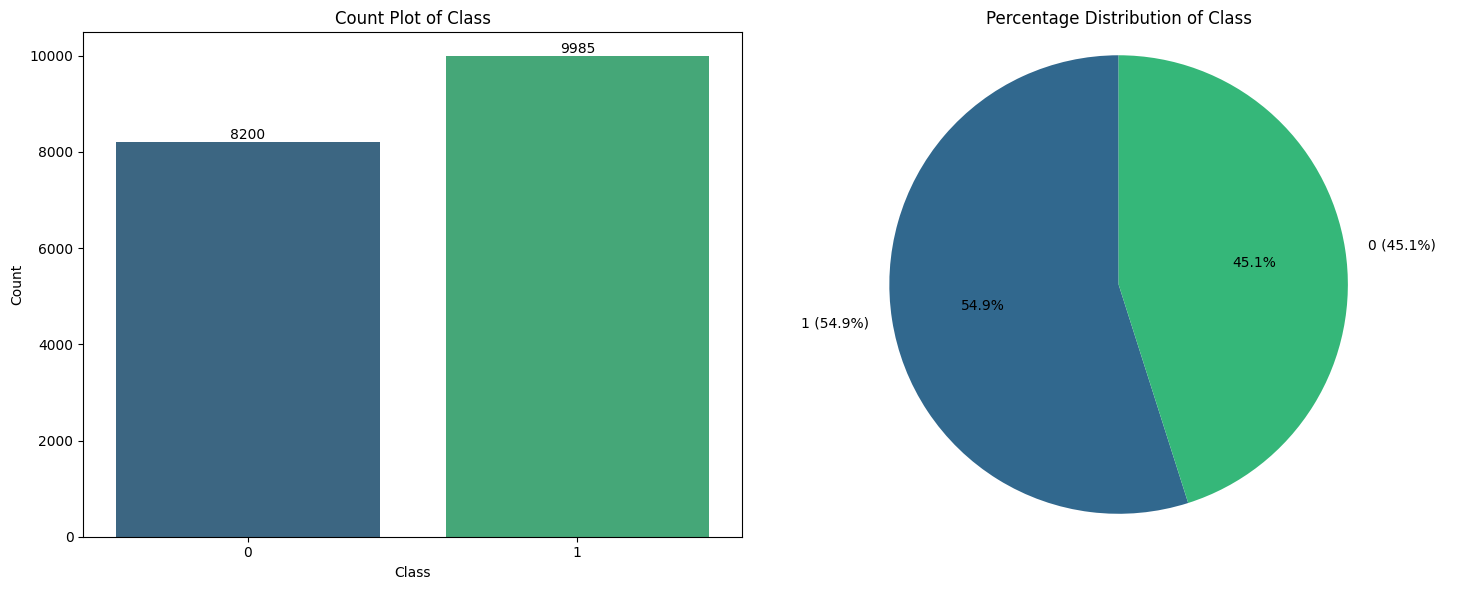

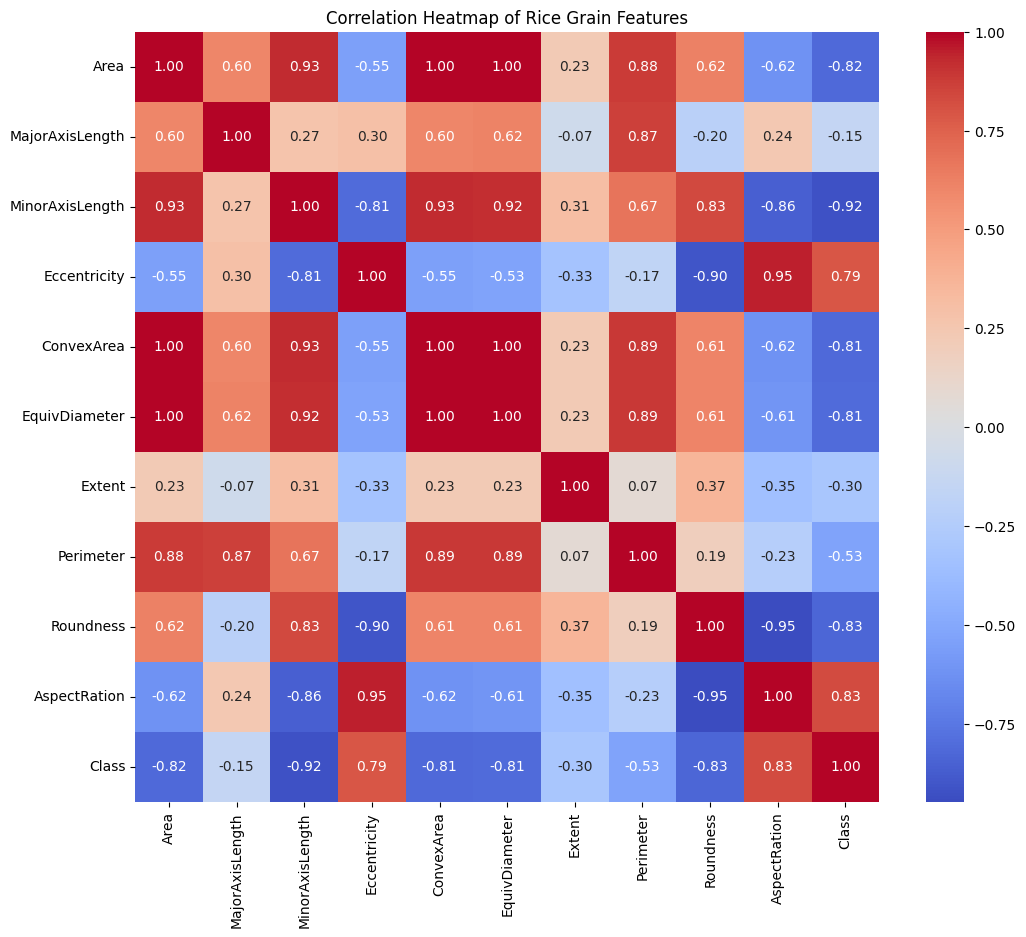

In [5]:
def plot_categorical_distribution(df, column_name):
    """
    Plots a count plot and a pie chart with percentages for a given categorical column.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column_name (str): The name of the categorical column to plot.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Count Plot
    sns.countplot(x=column_name, data=df, ax=axes[0], hue=column_name, palette='viridis', legend=False)
    axes[0].set_title(f'Count Plot of {column_name}')
    axes[0].set_xlabel(column_name)
    axes[0].set_ylabel('Count')

    # Add counts on top of bars
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

    # Pie Chart
    counts = df[column_name].value_counts()
    percentages = counts / len(df) * 100
    labels = [f'{idx} ({val:.1f}%)' for idx, val in zip(counts.index, percentages)]
    axes[1].pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(counts)))
    axes[1].set_title(f'Percentage Distribution of {column_name}')
    axes[1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

    plt.tight_layout()
    plt.show()

# Apply the function to the target column
plot_categorical_distribution(df, config.target)

# Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Rice Grain Features')
plt.show()

# Important Considerations:
1. consider handling class imbalance (downsampling is reasonable).

# Dataset and Dataloader:

<a id='preprocessing'></a>
## 4. Data Preprocessing
To prepare the data for the neural network, we:
* Split the data into Training (70%), Validation (15%), and Test (15%) sets.
* Scale the features using a `StandardScaler` (fitted only on training data) to handle different feature magnitudes.
* Implement a custom PyTorch `Dataset` and `DataLoader` for efficient batch processing.

In [6]:
def get_scaler(cfg: config = config()):
    if cfg.scaler == "standard":
        scaler = StandardScaler()
    elif cfg.scaler == "minmax":
        scaler = MinMaxScaler()
    elif cfg.scaler == "robust":
        scaler = RobustScaler()
    else:
        raise ValueError('scaler parameter should be one of "standard" , "minmax" , "robust"')
    return scaler

class RiceDataset(Dataset):
    """
    Custom PyTorch Dataset for rice type classification.
    """
    def __init__(self, df: pd.DataFrame, label: str = config.target, scaler = None):
        """
        Args:
            df (pd.DataFrame): The input DataFrame containing features and labels.
            label (str): the name of the target column.
            scaler: scaler for training, fitted scaler (for validation), or none for automatically initialize scaler based on the config class
        """
        features, target = df.drop(columns=[label]), df[label].values
        self._scaler = scaler or get_scaler()
        if scaler is None: # the scaler is not fitted
            self._fit_scaler(df=features)
        self.features = self._scaler.transform(features)
        self.target = target
        print("Dataset Initialized successfully")

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        features = torch.from_numpy(self.features[index]).float()
        target = torch.tensor(self.target[index]).float().unsqueeze(0)
        return features, target

    def _fit_scaler(self, df: pd.DataFrame):
        """
        A method to fit the dataset scaler
        Args:
            df: data to be fitted
        """
        print("Fitting Scaler")
        self._scaler.fit(df)
    def get_scaler(self):
        return self._scaler


def prepare_datasets(df):
    # using 70 15 15 strategy for train, val, test datasets
    x_train, x_test_full = train_test_split(df,test_size=0.3, stratify=df[config.target])
    x_test, x_val = train_test_split(x_test_full, test_size=0.5, stratify=x_test_full[config.target])
    return x_train, x_val, x_test

def get_loaders(df):
    train, val, test = prepare_datasets(df)
    train_ds = RiceDataset(train)
    # Initialize the val/test datasets with the train dataset scaler to avoid data leackage
    val_ds = RiceDataset(val, scaler = train_ds.get_scaler())
    test_ds = RiceDataset(test, scaler = train_ds.get_scaler())

    train_dataloader = DataLoader(
        train_ds, shuffle=True,drop_last=True, **config().dataloader_configs
    )
    val_dataloader = DataLoader(
        val_ds, shuffle=False, **config().dataloader_configs
    )
    test_dataloader = DataLoader(
        test_ds, shuffle=False, **config().dataloader_configs
    )
    return train_dataloader, val_dataloader, test_dataloader

# Modelling :

<a id='modelling'></a>
## 5. Model Architecture
We define a Deep Neural Network using `nn.Module`. The architecture consists of fully connected layers with ReLU activations and Dropout for regularization to prevent overfitting.

## Model architecture:

In [7]:
class FullyConnectedLayer(nn.Module):
    """
    Fully connected layer with ReLU activation.
    """
    def __init__(self, in_features: int, out_features: int, dropout_rate: float = 0.2):
        """
        Args:
            in_features (int): Number of input features
            out_features (int): Number of output features
            dropout_rate (float, optional): Dropout rate. Defaults to 0.2
        """
        super(FullyConnectedLayer, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(in_features, out_features),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
    def forward(self, x):
        return self.fc(x)


class RiceTypeClassifier(nn.Module):
    """
    Deep learning model for rice type classification.
    Architecture: 2 hidden layers with ReLU activation:
    - Input layer: 64 neurons
    - Hidden layer 1: 128 neurons
    - Hidden layer 2: 64 neurons
    - Output layer: 1 neurons (binary classification)
    """
    def __init__(self, input_size: int):
        """
        Args:
            input_size (int): Number of input features.
        """
        super(RiceTypeClassifier, self).__init__()

        # building the architecture:
        self.net = nn.Sequential(
            FullyConnectedLayer(input_size, 128),
            FullyConnectedLayer(128, 64),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x)

# Training

<a id='training'></a>
## 6. Training and Evaluation
We use binary cross-entropy with logits as the loss function and train the model using a custom `Trainer` class. We monitor loss and accuracy curves for both training and validation sets.

In [8]:
# 1. prepare the datasets
train_dataloader, val_dataloader, test_dataloader = get_loaders(df)

# 2. prepare the criterion and model
criterion = nn.BCEWithLogitsLoss()
model = RiceTypeClassifier(len(train_dataloader.dataset[0][0])).to(config.device)

Fitting Scaler
Dataset Initialized successfully
Dataset Initialized successfully
Dataset Initialized successfully


In [9]:
# 3. importing the trainer
from utilities import Trainer, TrainerConfig

train_config=TrainerConfig(
    task_type="binary",
    epochs=config.num_epochs,
    lr=config.learning_rate,
    device=config.device
)

trainer = Trainer(
    model=model,
    config=train_config,
    criterion=criterion, train_loader=train_dataloader,
    val_loader=val_dataloader
    )

In [10]:
history = trainer.fit()

Starting pipeline on device: cpu (Task: binary)


Epoch [1/10] -> Train Loss: 0.1012 | Acc: 97.80% | F1: 0.9778 || Val Loss: 0.0291 | Acc: 99.08% | F1: 0.9907
🏆 Best validation loss updated to 0.0291. Model saved.


Epoch [2/10] -> Train Loss: 0.0379 | Acc: 98.75% | F1: 0.9873 || Val Loss: 0.0278 | Acc: 99.05% | F1: 0.9904
🏆 Best validation loss updated to 0.0278. Model saved.


Epoch [3/10] -> Train Loss: 0.0359 | Acc: 98.86% | F1: 0.9884 || Val Loss: 0.0267 | Acc: 99.19% | F1: 0.9919
🏆 Best validation loss updated to 0.0267. Model saved.


Epoch [4/10] -> Train Loss: 0.0345 | Acc: 98.85% | F1: 0.9884 || Val Loss: 0.0266 | Acc: 99.08% | F1: 0.9907
🏆 Best validation loss updated to 0.0266. Model saved.


...

Epoch [6/10] -> Train Loss: 0.0325 | Acc: 98.91% | F1: 0.9890 || Val Loss: 0.0252 | Acc: 99.16% | F1: 0.9915
🏆 Best validation loss updated to 0.0252. Model saved.


Epoch [7/10] -> Train Loss: 0.0327 | Acc: 98.90% | F1: 0.9889 || Val Loss: 0.0260 | Acc: 99.08% | F1: 0.9907


Epoch [8/10] -> Train Loss: 0.0335 | Acc: 98.82% | F1: 0.9881 || Val Loss: 0.0260 | Acc: 99.12% | F1: 0.9911


Epoch [9/10] -> Train Loss: 0.0322 | Acc: 98.90% | F1: 0.9888 || Val Loss: 0.0256 | Acc: 99.08% | F1: 0.9907


Epoch [10/10] -> Train Loss: 0.0315 | Acc: 98.97% | F1: 0.9896 || Val Loss: 0.0254 | Acc: 99.08% | F1: 0.9907


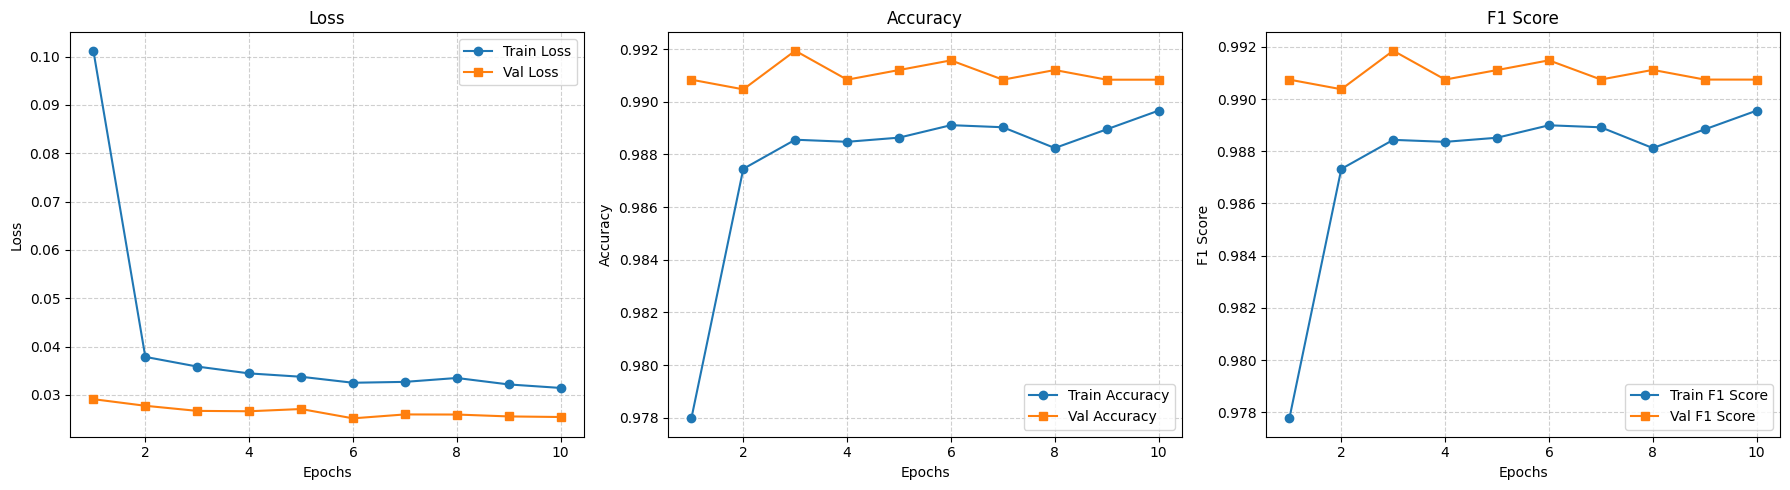

In [11]:
trainer.plot_metrics()

In [12]:
test_loss, test_acc, test_f1 = trainer.evaluate(test_dataloader)

In [13]:
print(
    f"Test Loss: {test_loss:.4f}\n",
    f"Test Accuracy: {test_acc:.4f}\n",
    f"Test F1 Score: {test_f1:.4f}"
)

Test Loss: 0.0354
 Test Accuracy: 0.9890
 Test F1 Score: 0.9889


# Why the accuracy is very high ?
* Lets check out feature distribution per class to check if feature are actually have seperable decision boundries per class :

<a id='analysis'></a>
## 7. Result Analysis
Finally, we analyze why the model achieves high performance by visualizing the feature distributions per class.

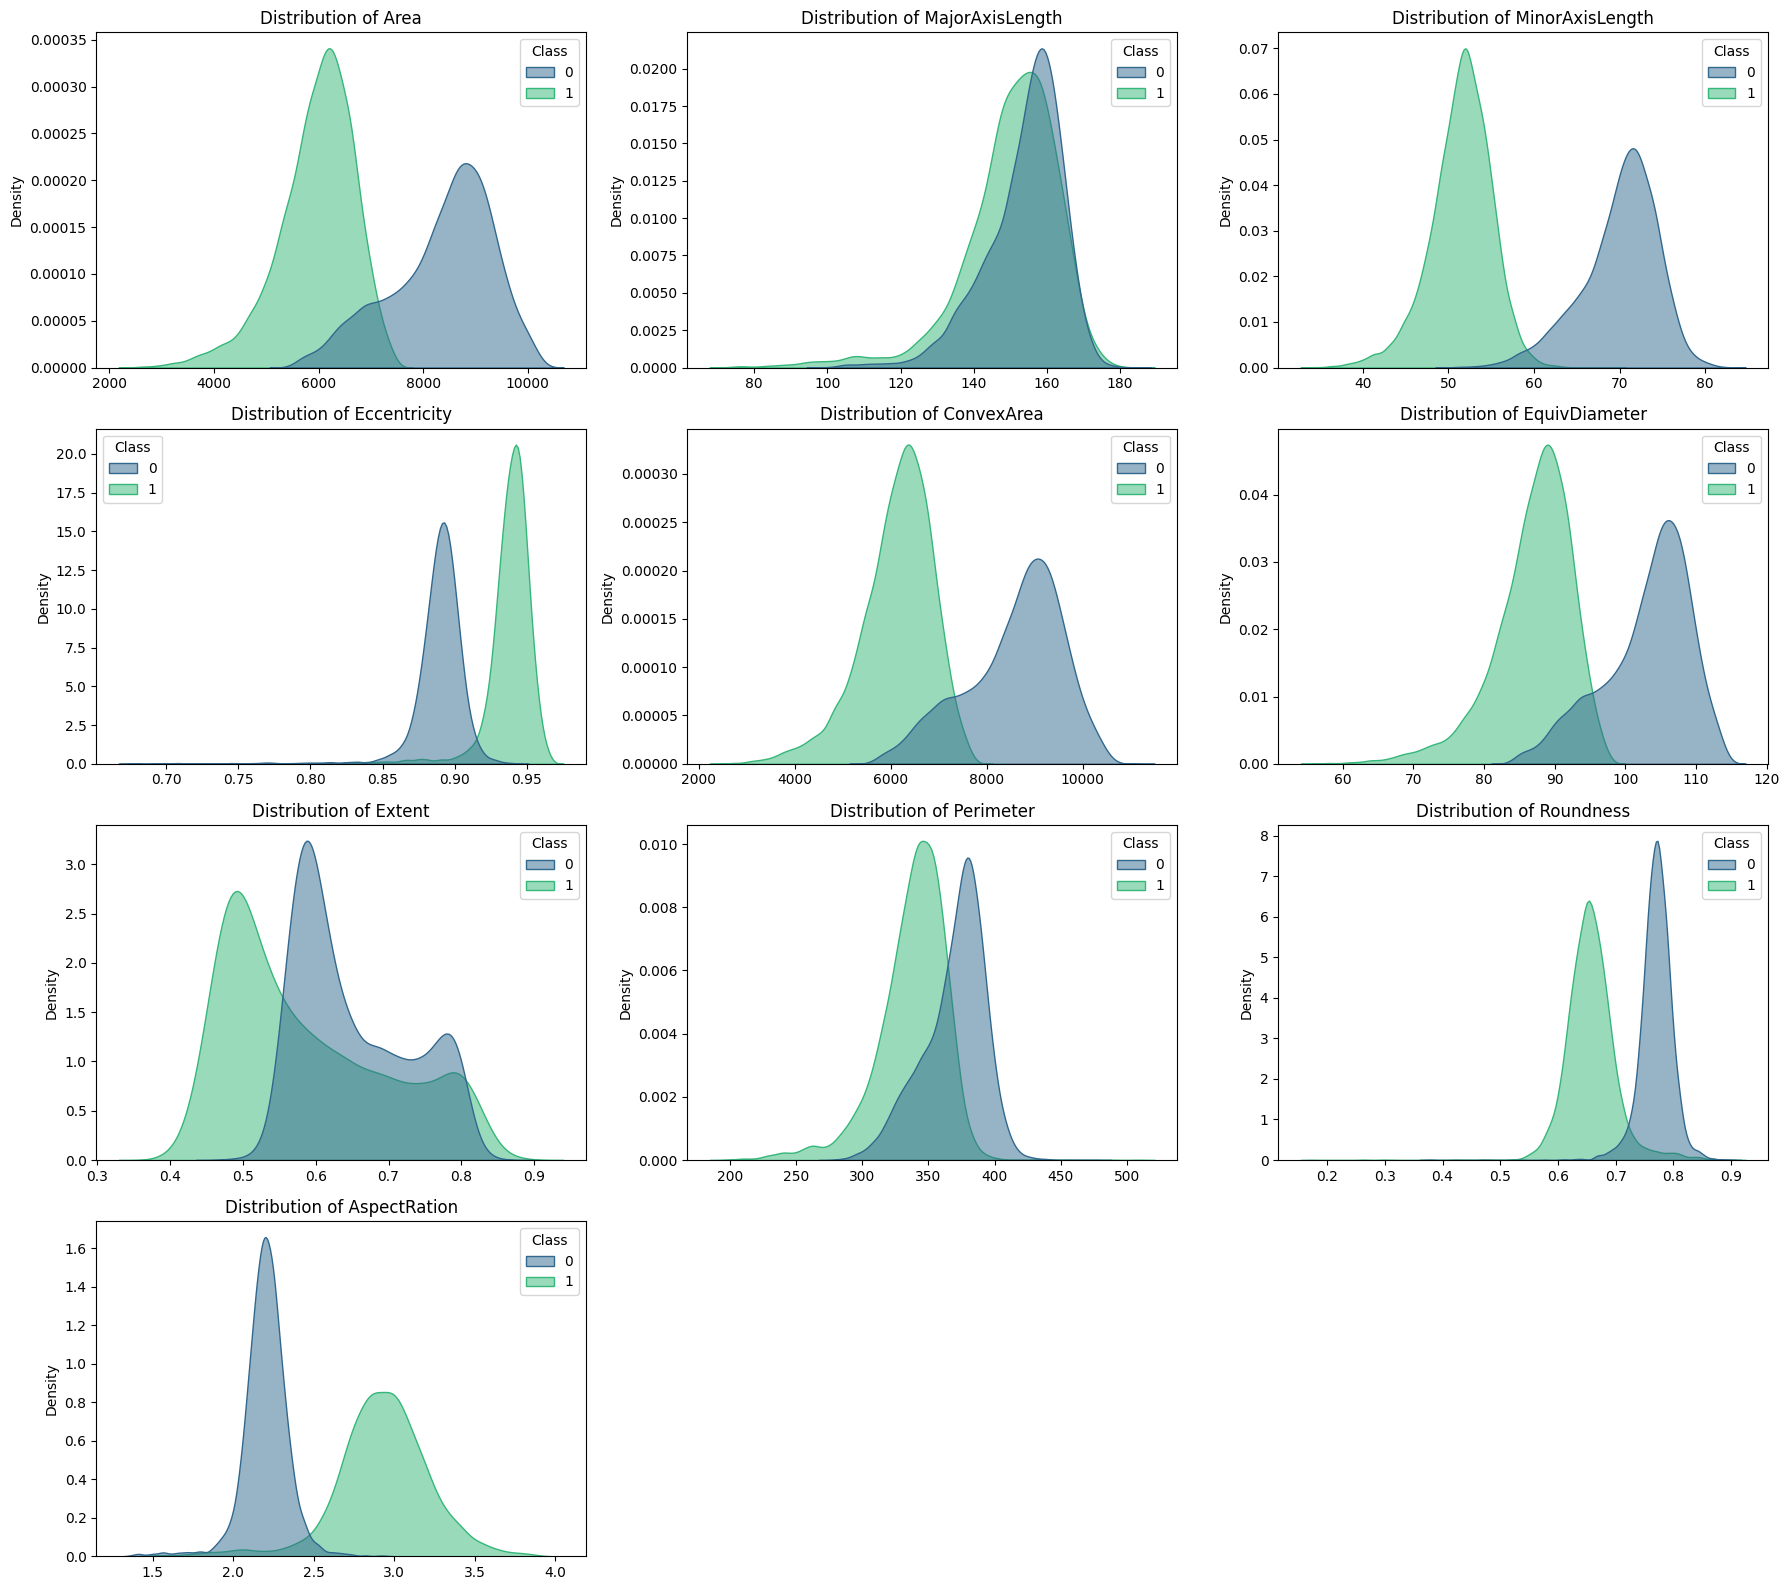

In [14]:
import math

def plot_feature_distributions(df, target_col):
    features = [col for col in df.columns if col != target_col]
    n_features = len(features)
    cols = 3
    rows = math.ceil(n_features / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(features):
        sns.kdeplot(data=df, x=col, hue=target_col, fill=True, ax=axes[i], palette='viridis', alpha=0.5)
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel('')

    # Hide any empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

plot_feature_distributions(df, config.target)

### Because the distributions for these features have very little overlap, the neural network can easily find a decision boundary that perfectly classifies the grains.

# 5. Complete Application Code
The following cell writes the Streamlit application to a file named `app.py`.

In [15]:
import pickle

# Save objects for Streamlit to access
artifacts = {
    'model_state': model.state_dict(),
    'input_size': len(train_dataloader.dataset[0][0]),
    'scaler': train_dataloader.dataset.get_scaler(),
    'target_col': config.target,
    'feature_cols': [col for col in df.columns if col != config.target],
    'df_stats': df.describe().to_dict()
}
with open('app_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Artifacts saved. Writing app.py...")

app_code = """
import streamlit as st
import torch
import torch.nn as nn
import pandas as pd
import pickle
import numpy as np

class FullyConnectedLayer(nn.Module):
    def __init__(self, in_features, out_features, dropout_rate=0.2):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(in_features, out_features), nn.ReLU(), nn.Dropout(dropout_rate))
    def forward(self, x): return self.fc(x)

class RiceTypeClassifier(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(FullyConnectedLayer(input_size, 128), FullyConnectedLayer(128, 64), nn.Linear(64, 1))
    def forward(self, x): return self.net(x)

@st.cache_resource
def load_resources():
    with open('app_artifacts.pkl', 'rb') as f:
        data = pickle.load(f)
    model = RiceTypeClassifier(data['input_size'])
    model.load_state_dict(data['model_state'])
    model.eval()
    return model, data['scaler'], data['feature_cols'], data['df_stats']

model, scaler, feature_cols, df_stats = load_resources()

st.title("🌾 Rice Type Classifier")

st.sidebar.header("Input Features")
inputs = {}
for col in feature_cols:
    min_v, max_v, mean_v = df_stats[col]['min'], df_stats[col]['max'], df_stats[col]['mean']
    inputs[col] = st.sidebar.slider(col, float(min_v), float(max_v), float(mean_v))

if st.button("Predict"):
    input_df = pd.DataFrame([inputs])
    scaled_features = scaler.transform(input_df)
    features_tensor = torch.FloatTensor(scaled_features)
    with torch.no_grad():
        logits = model(features_tensor)
        prob = torch.sigmoid(logits).item()
        prediction = "Osmancik" if prob > 0.5 else "Cammeo"
        confidence = prob if prob > 0.5 else 1 - prob
    st.metric("Result", prediction, f"{confidence*100:.2f}% Confidence")
"""

with open('app.py', 'w') as f:
    f.write(app_code)

Artifacts saved. Writing app.py...


# 6. Notebook Launch Instructions
To run this in Google Colab, we use `localtunnel` to create a public URL.

In [16]:
!pip install streamlit --quiet

import subprocess
import time
from google.colab import output

# Terminate any existing streamlit process
!fuser -k 8501/tcp

# Start app with specific headless configurations for Colab
subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.headless", "true",
    "--server.enableCORS", "false",
    "--server.enableXsrfProtection", "false"
])

# Wait for server to initialize
print("Waiting for Streamlit to start...")
time.sleep(8)

# Get the Colab proxy URL
from google.colab.output import eval_js
proxy_url = eval_js("google.colab.kernel.proxyPort(8501)")

print(f"App is running! If the window below doesn't load, click here: {proxy_url}")

# Embed using the verified proxy URL
output.serve_kernel_port_as_iframe(8501, height='700')


Waiting for Streamlit to start...
App is running! If the window below doesn't load, click here: https://8501-m-s-kkb-ase1a2-2mkcqb7gpg8zn-a.asia-east1-2.prod.colab.dev


<IPython.core.display.Javascript object>